!PCA FROM SCRATCH 

In [1]:
import pandas as pd
import matplotlib as plt
import numpy as np

In [2]:
def mean(x):
    total = 0
    for i in range(0,150): 
        total += x[i]
    return total/len(x)

In [3]:
from sklearn.datasets import load_iris
df = load_iris(as_frame=True)

In [4]:
df.data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
x = df.data.iloc[:, 0:4]
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [6]:
for i in range(0,4):
    cen = []
    col = x.iloc[:,i]
    x_mean = mean(col)
    for j in range(0,150):
        cen.append(col[j]-x_mean)
    x.iloc[:,i] = cen

In [7]:
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.743333,0.442667,-2.358,-0.999333
1,-0.943333,-0.057333,-2.358,-0.999333
2,-1.143333,0.142667,-2.458,-0.999333
3,-1.243333,0.042667,-2.258,-0.999333
4,-0.843333,0.542667,-2.358,-0.999333
...,...,...,...,...
145,0.856667,-0.057333,1.442,1.100667
146,0.456667,-0.557333,1.242,0.700667
147,0.656667,-0.057333,1.442,0.800667
148,0.356667,0.342667,1.642,1.100667


In [8]:
#COVARIANCE MATRIX

cov = [[0 for i in range(4)] for j in range(4)]
cov

[[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]

In [9]:
for i in range(4):
    for j in range(4):
        sum = 0
        a = x.iloc[:,i]
        b = x.iloc[:,j]
        for k in range(0,150):
            sum +=a[k]*b[k]
        cov[i][j] = sum/149

In [10]:
cov

[[np.float64(0.6856935123042505),
  np.float64(-0.04243400447427291),
  np.float64(1.2743154362416103),
  np.float64(0.5162706935123044)],
 [np.float64(-0.04243400447427291),
  np.float64(0.1899794183445188),
  np.float64(-0.32965637583892626),
  np.float64(-0.12163937360178978)],
 [np.float64(1.2743154362416103),
  np.float64(-0.32965637583892626),
  np.float64(3.1162778523489942),
  np.float64(1.2956093959731536)],
 [np.float64(0.5162706935123044),
  np.float64(-0.12163937360178978),
  np.float64(1.2956093959731536),
  np.float64(0.5810062639821029)]]

In [11]:
def minor(mat , row , col ): 
    min = []
    for i  in range(len(mat)):
        min_row = []
        if i == row:
            continue 

        for j in range(len(mat)):
            if j==col: 
                continue
        
            min_row = min.append(mat[i][j])
        
        min = min.apppend(min_row)
    
    return min



In [12]:
def determinant(matrix):

    n = len(matrix)

    if n ==1 :
        return matrix[0][0]

    if n==2 : 
        return matrix[0][0]*matrix[1][1] - matrix[0][1]*matrix[1][0]
    
    det = 0

    for col in range(n):
        sign = (-1)**col
        minor_mat = minor(matrix , 0 , col)
        det += sign*matrix[0][col]*determinant(minor_mat)

    return det


In [13]:
def mat_mul(mat1,mat2):
    if len(mat1[0]) == len(mat2):
        mat3 = [[0 for j in range(len(mat2[0]))] for i in range(len(mat1))]
        for i in range(len(mat1)):
            for j in range(len(mat2[0])):
                for k in range(len(mat1[0])):
                    mat3[i][j] += mat1[i][k] * mat2[k][j]
        return mat3
    else:
        print("Incompatible matrix dimensions")

In [14]:
v = [[1],[1],[1],[1]]
v

[[1], [1], [1], [1]]

In [15]:
l = [[1],[1],[1],[1]]

In [16]:
lv = mat_mul(l,v)
lv

Incompatible matrix dimensions


In [17]:
def dot(vec1,vec2):
    if len(vec1) == len(vec2):
        sum = 0
        for i in range(len(vec1)):
            sum += vec1[i]*vec2[i]
        return sum
    else:
        print("Incompatible vector lengths")

In [18]:
def normalize(vec):
    sum=0
    for i in range(len(vec)):
        sum += vec[i][0]**2

    norm = sum**(0.5)

    for i in range(len(vec)):
        vec[i] = vec[i]/norm

    return vec

In [19]:
def pwr_it(mat,it=100):
    v = [[1],[1],[1],[1]]
    
    for i in range(1,it):
        v = mat_mul(mat,v)
        v = normalize(v)
    
    return v

In [20]:
def eigenval(mat,vec):

    return dot(vec,(mat_mul(mat,vec)))/dot(vec,vec) 

In [21]:
def transpose(mat):
    mat_t = [ [1 for i in range(len(mat)) ] for j in range(len(mat[0]))]

    for i in range(len(mat)):

        for j in range(len(mat[0])):
            mat_t[j][i] = mat[i][j]

    return mat_t


In [22]:
def mat_sub(a,b):
    if len(a) == len(b) and len(a[0]) == len(b[0]):
        mat3 = [[0 for j in range(len(a[0]))] for i in range(len(a))]
        for i in range(len(a)):
            for j in range(len(a[0])):
                mat3[i][j] = a[i][j] - b[i][j]
        return mat3
    else:
        print("Incompatible matrix dimensions")

In [30]:
vec = []
val = []

for i in range(0,4):
    vec.append(pwr_it(cov))
    
    
    val.append(eigenval(cov,vec[i]))

    out = mat_mul(vec[i],transpose(vec[i]))

    for i in range(0,4):
        for j in range(0,4):
            out[i][j] = out[i][j]*val[-1]
        
    cov = mat_sub(cov,out)    
    



In [24]:
vec

[[array([0.36138659]),
  array([-0.08452251]),
  array([0.85667061]),
  array([0.3582892])],
 [array([[0.65658877]]),
  array([[0.73016143]]),
  array([[-0.17337266]]),
  array([[-0.07548102]])],
 [array([[[-0.58202985]]]),
  array([[[0.59791083]]]),
  array([[[0.07623608]]]),
  array([[[0.54583143]]])],
 [array([[[[0.31548719]]]]),
  array([[[[-0.3197231]]]]),
  array([[[[-0.47983899]]]]),
  array([[[[0.75365743]]]])]]

In [26]:
val 

[array([4.22824171]),
 array([[0.24267075]]),
 array([[[0.0782095]]]),
 array([[[[0.02383509]]]])]

In [31]:
val = [
    4.22824171,
    0.24267075,
    0.07820950,
    0.02383509
]
vec = [
    [
        0.36138659,
       -0.08452251,
        0.85667061,
        0.35828920
    ],

    [
        0.65658877,
        0.73016143,
       -0.17337266,
       -0.07548102
    ],

    [
       -0.58202985,
        0.59791083,
        0.07623608,
        0.54583143
    ],

    [
        0.31548719,
       -0.31972310,
       -0.47983899,
        0.75365743
    ]
]

In [32]:
vec

[[0.36138659, -0.08452251, 0.85667061, 0.3582892],
 [0.65658877, 0.73016143, -0.17337266, -0.07548102],
 [-0.58202985, 0.59791083, 0.07623608, 0.54583143],
 [0.31548719, -0.3197231, -0.47983899, 0.75365743]]

In [33]:
val

[4.22824171, 0.24267075, 0.0782095, 0.02383509]

In [34]:
W = [
    [0.36138659,  0.65658877],
    [-0.08452251, 0.73016143],
    [0.85667061, -0.17337266],
    [0.35828920, -0.07548102]
]

In [36]:
x = x.values.tolist()
z = mat_mul(x,W)

In [37]:
z


[[-2.684125635240003, 0.3193972389133322],
 [-2.714141698240003, -0.1770012300866673],
 [-2.8889905792400032, -0.14494943208666722],
 [-2.745342865240003, -0.31829898408666774],
 [-2.7287165452400033, 0.3267545049133325],
 [-2.2808596392400027, 0.7413304399133326],
 [-2.820537759240003, -0.08946139108666792],
 [-2.6261449822400027, 0.16338495291333244],
 [-2.886382742240003, -0.5783117580866676],
 [-2.672755808240003, -0.11377425108666725],
 [-2.5069470992400027, 0.6450688899133328],
 [-2.612755239240003, 0.014729932913332286],
 [-2.786109277240003, -0.2351120050866677],
 [-3.223803755240003, -0.5113945920866677],
 [-2.644750399240003, 1.1787646249133323],
 [-2.386039039240003, 1.3380623179133326],
 [-2.623527883240003, 0.8106795039133325],
 [-2.648296715240003, 0.31184913691333216],
 [-2.1998203312400024, 0.8728390299133325],
 [-2.587986407240003, 0.5135602999133322],
 [-2.3102562242400024, 0.39134592891333264],
 [-2.543705236240003, 0.4329960549133324],
 [-3.215939425240003, 0.133468

In [38]:
print(len(x))
print(len(x[0]))

print(len(W))
print(len(W[0]))

150
4
4
2


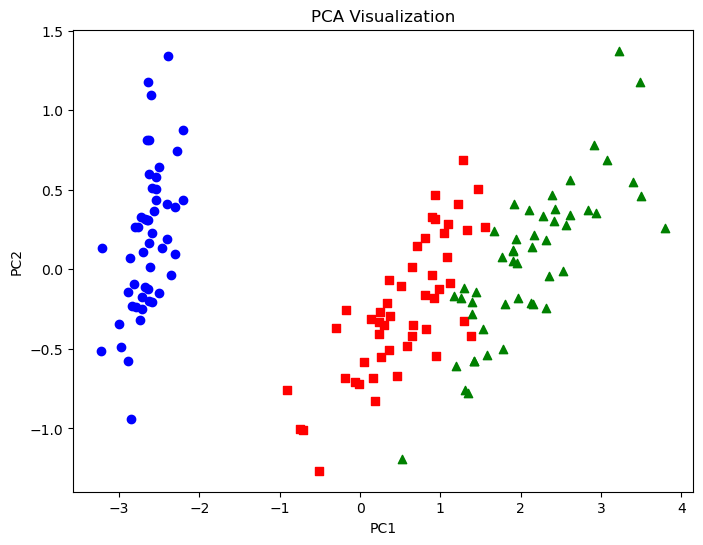

In [41]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(8,6))

for i in range(len(z)):

    if df.target[i] == 0:
        plt.scatter(z[i][0], z[i][1], marker='o',color='blue')

    elif df.target[i] == 1:
        plt.scatter(z[i][0], z[i][1], marker='s', color='red')

    else:
        plt.scatter(z[i][0], z[i][1], marker='^', color='green')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")
plt.show()

In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

z_sklearn = pca.fit_transform(x)

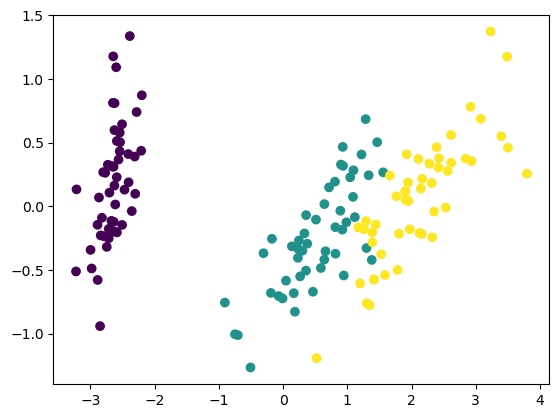

In [45]:
plt.scatter(z_sklearn[:,0],
            z_sklearn[:,1],
            c=df.target)


In [47]:
check1 = dot(vec[0],vec[1])
check1

3.18329844081755e-09